In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
# load vis_objects
vis_objects = pd.read_csv('./dataset/vis_objects_set.csv')
vis_objects = vis_objects.iloc[:,1:] # drop row called Unnamed:0 with indices

In [20]:
vis_objects = vis_objects[vis_objects['distance'] < 100000]
vis_objects

,name,alt_name,ra,dec,vmag,multiple,class,bii,lii,parallax,distance,absmag
0,HR 7228,SigOct,21 08 46.20,-88 57 23.0,5.47,NaN,STARF0III,-27.7134,303.905,NaN,294.099529,-1.872472
1,HR 8294,NaN,22 45 28.61,-88 49 05.9,6.57,NaN,STARF0IV,-28.1341,303.632,NaN,337.985884,-1.074493
2,HR 5491,NaN,15 28 19.10,-88 07 59.2,6.48,NaN,STARA0,-25.6758,304.242,NaN,212.479725,-0.156587
3,HR 6721,ChiOct,18 54 46.90,-87 36 20.9,5.28,NaN,STARK3III,-27.1375,305.622,NaN,257.221118,-1.771533
4,HR 6133,NaN,17 15 59.30,-87 33 59.0,6.57,NaN,STARG5III,-26.1220,305.411,NaN,643.306465,-2.472090
...,...,...,...,...,...,...,...,...,...,...,...,...
9105,HR 8938,NaN,23 27 00.79,+87 18 27.0,5.58,NaN,STARA7IV,24.6125,121.866,NaN,316.656677,-1.922943
9106,HR 4686,NaN,12 15 20.30,+87 42 00.0,6.28,NaN,STARF2V,29.3993,123.346,NaN,158.098099,0.285367
9107,HR 286,NaN,01 33 50.40,+89 00 56.2,6.46,NaN,STARA3V,26.1606,123.134,NaN,333.152582,-1.153216
9108,HR 7394,LamUMi,17 16 56.81,+89 02 16.1,6.38,W,STARM1III,27.5104,121.938,NaN,879.127703,-3.340260


In [23]:
np.arccos(1)

np.float64(0.0)

In [44]:
gal_df = vis_objects[['alt_name', 'bii', 'lii', 'distance', 'absmag']]
gal_df = gal_df.loc[(gal_df != 0).all(axis=1)].dropna(subset=['bii', 'lii', 'distance', 'absmag']) # drop zeroes and na
sun_dict = {'alt_name': 'Sun', 'bii': 0, 'lii': 0, 'distance': 0, 'absmag': 4.83}
gal_df = pd.concat([gal_df, pd.DataFrame(sun_dict, index=[0])], ignore_index=True) # add sun to bottom
gal_df.reset_index(drop=True, inplace=True)
R_sun = 26000 # lyr roughly
gal_df['R'] = np.sqrt((R_sun*np.sin(gal_df['lii']*np.pi/180))**2 + (gal_df['distance'] - R_sun*np.cos(gal_df['lii']*np.pi/180))**2) # lii is longitude bii is latitude
def get_gal_phi(star):
    return np.arccos((star['distance']**2 - R_sun**2 - star['R']**2) / (-2*R_sun*star['R'])) * 180/np.pi
gal_df['phi'] = gal_df.apply(lambda star: get_gal_phi(star) if star['lii'] < 180 else (360 - get_gal_phi(star)), axis=1)
gal_df[gal_df['alt_name'] == 'Sun']

,alt_name,bii,lii,distance,absmag,R,phi
9061,Sun,0.0,0.0,0.0,4.83,26000.0,0.0


In [68]:
test_R = 1000
test_d = 10000
test_theta = 5*np.pi/180
test_l = np.sqrt((test_R*np.sin(test_theta))**2 + (test_d - test_R*np.cos(test_theta))**2)

In [69]:
test_l

np.float64(9004.227120534282)

In [70]:
np.arccos((test_d**2 - test_R**2 - test_l**2) / (-2*test_R*test_l)) * 180/np.pi

np.float64(174.44540112846892)

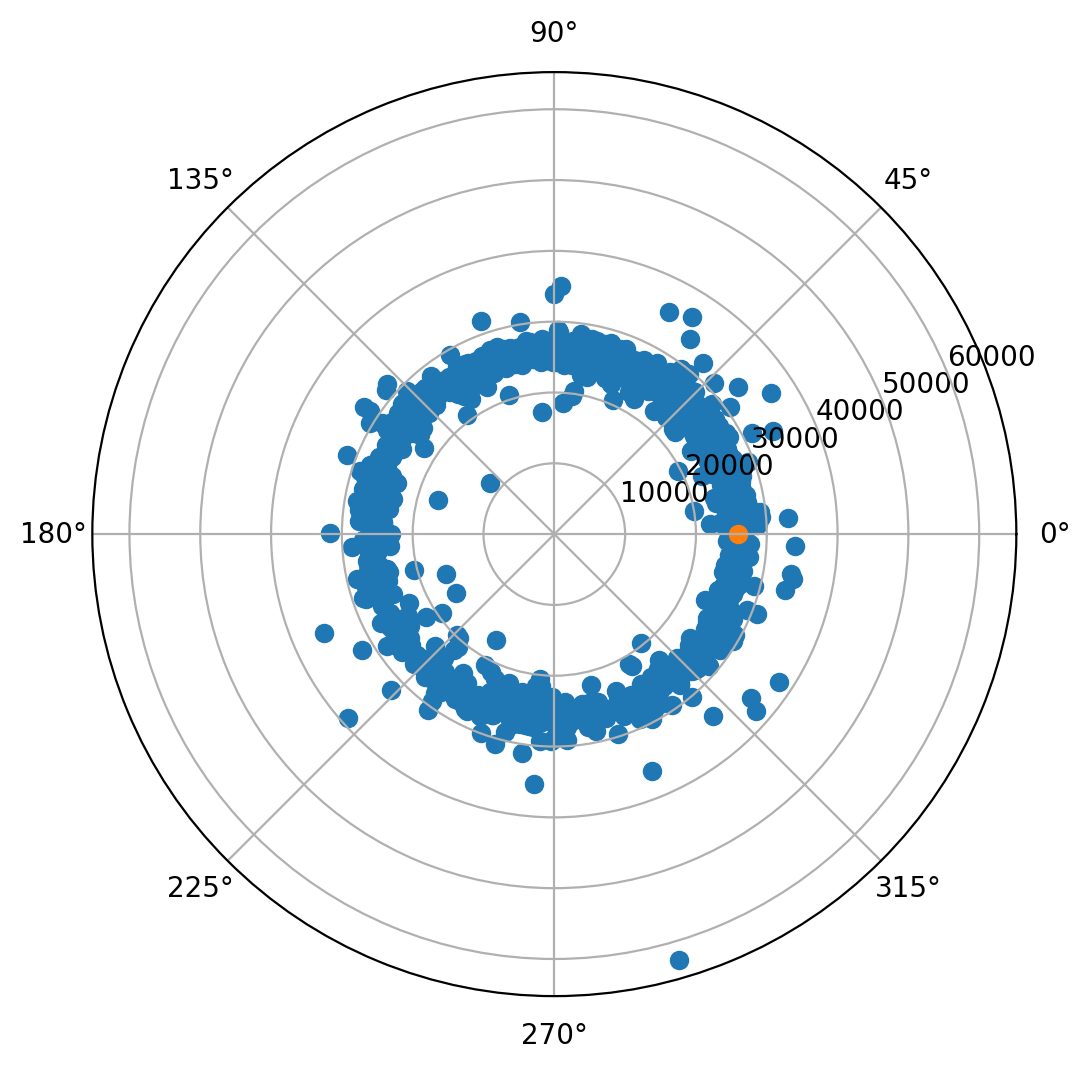

In [45]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=(6,6)) 
ax.scatter(gal_df['phi'], gal_df['R'])
ax.scatter(0, 26000)

In [30]:
gal_df['R'].min()

np.float64(11554.081706655112)

In [3]:
# functions
def ra_to_degree(star):
    ls = star.split(' ')
    return 360/24*(float(ls[0]) + float(ls[1])/60 + float(ls[2])/3600)
def dec_to_degree(star):
    ls = star.split(' ')
    if ls[0][0] == '-':
        return -1*(float(ls[0][1:]) + float(ls[1])/60 + float(ls[2])/3600)
    else:
        return float(ls[0]) + float(ls[1])/60 + float(ls[2])/3600

gal_loc_df = vis_objects[['alt_name', 'ra', 'dec', 'distance', 'absmag', 'vmag']].copy()
gal_loc_df = gal_loc_df.loc[(gal_loc_df != 0).all(axis=1)].dropna(subset=['ra', 'dec', 'distance', 'absmag']) # drop zeroes and na
gal_loc_df.reset_index(drop=True, inplace=True)
sun_dict = {'alt_name': 'Sun', 'ra': '0 0 0.0', 'dec': '0 0 0.0', 'distance': 0, 'absmag': 4.83, 'vmag': 'Nan'}
gal_center_dict = {'alt_name': 'Milky Way Core', 'ra': '17 45 36.0', 'dec': '-28 55 58.8', 'distance': 26000, 'absmag': 0, 'vmag': 'Nan'}
gal_loc_df = pd.concat([gal_loc_df, pd.DataFrame(sun_dict, index=[0]), pd.DataFrame(gal_center_dict, index=[0])], ignore_index=True) # add sun to bottom
gal_loc_df['ra'] = gal_loc_df['ra'].apply(ra_to_degree)
gal_loc_df['dec'] = gal_loc_df['dec'].apply(dec_to_degree)
gal_loc_df['sun_x'] = gal_loc_df['distance']*np.cos(gal_loc_df['dec']*np.pi/180)*np.cos(gal_loc_df['ra']*np.pi/180)
gal_loc_df['sun_y'] = gal_loc_df['distance']*np.cos(gal_loc_df['dec']*np.pi/180)*np.sin(gal_loc_df['ra']*np.pi/180)
gal_loc_df['sun_z'] = gal_loc_df['distance']*np.sin(gal_loc_df['dec']*np.pi/180)
gal_center_index = gal_loc_df.loc[gal_loc_df['alt_name'] == 'Milky Way Core'].index[0]
gal_loc_df['center_x'] = gal_loc_df['sun_x'] - gal_loc_df.iloc[gal_center_index]['sun_x']
gal_loc_df['center_y'] = gal_loc_df['sun_y'] - gal_loc_df.iloc[gal_center_index]['sun_y']
gal_loc_df['center_z'] = gal_loc_df['sun_z'] - gal_loc_df.iloc[gal_center_index]['sun_z']
gal_loc_df['center_dist'] = np.sqrt(gal_loc_df['sun_x']**2 + gal_loc_df['sun_y']**2 + gal_loc_df['sun_z']**2)

In [13]:
gal_loc_df = gal_loc_df[gal_loc_df['center_dist'] < 50000]

<Axes: >

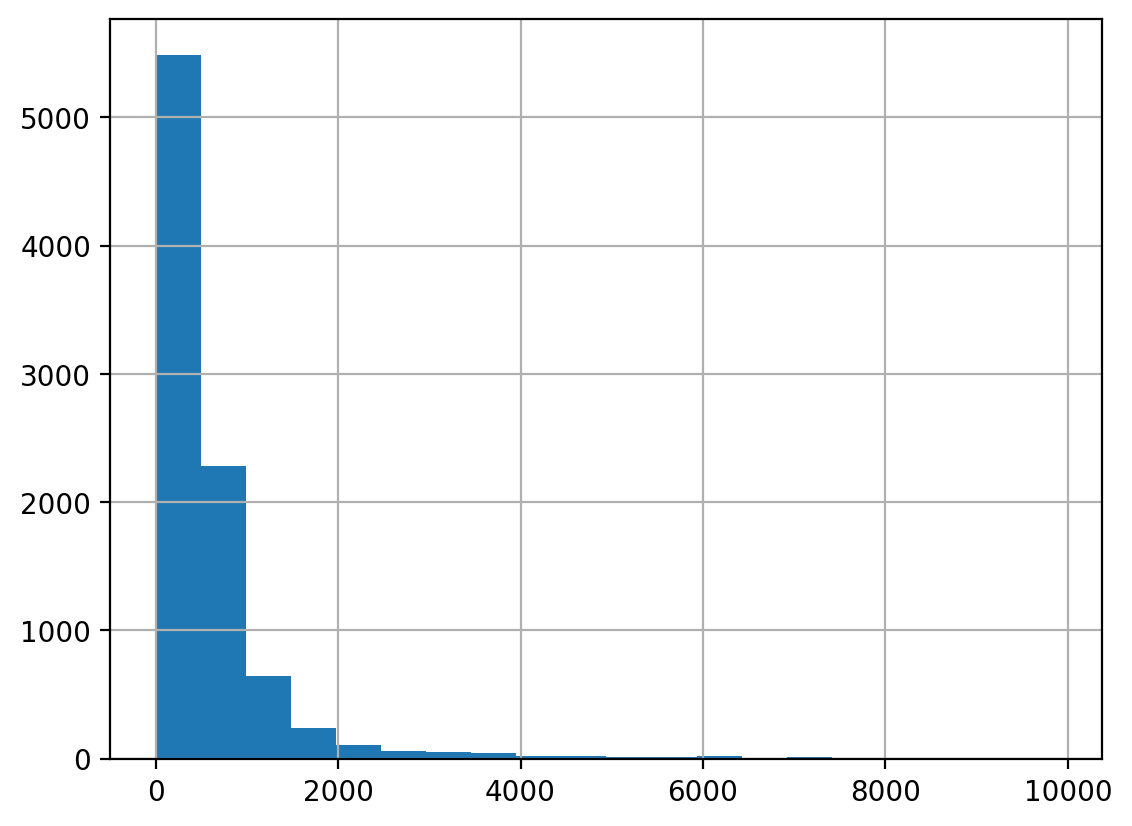

In [14]:
gal_loc_df['center_dist'].hist(bins=20)

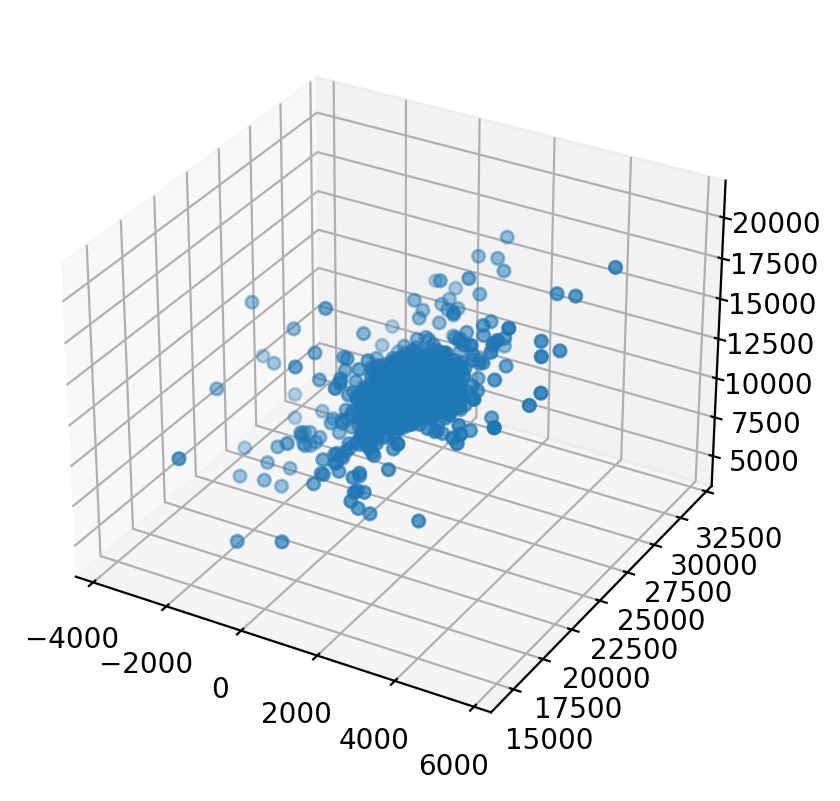

In [15]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(gal_loc_df['center_x'], gal_loc_df['center_y'], gal_loc_df['center_z'])